In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

plt.rcParams["figure.figsize"] = (8, 6)
import os
print(os.getcwd())
print(os.listdir('.'))

from google.colab import files
uploaded = files.upload()


/content
['.config', 'sample_data']


Saving photo.jpeg to photo.jpeg


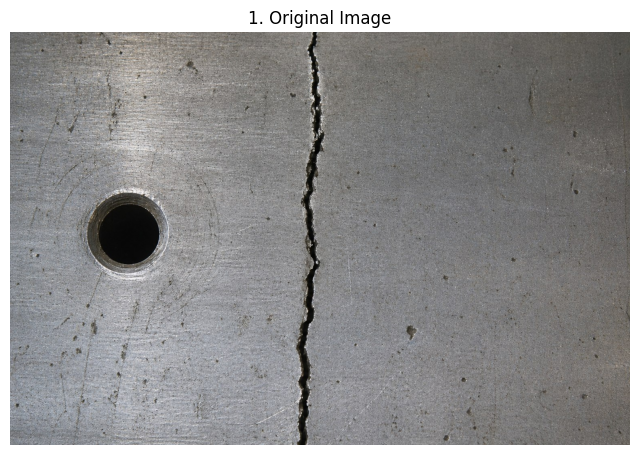

In [3]:
img = cv2.imread('photo.jpeg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title('1. Original Image')
plt.axis('off')
plt.show()


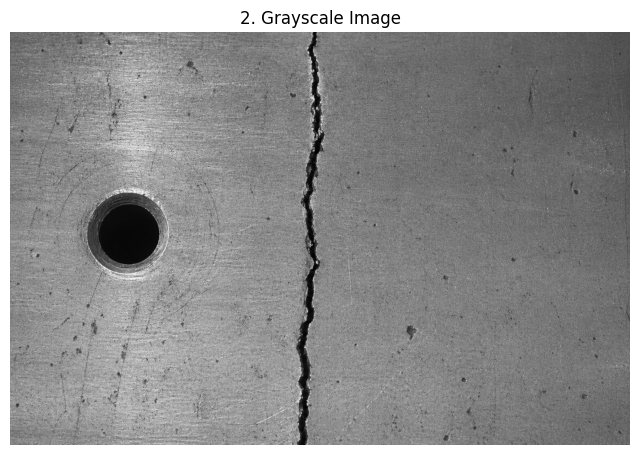

In [4]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap='gray')
plt.title('2. Grayscale Image')
plt.axis('off')
plt.show()

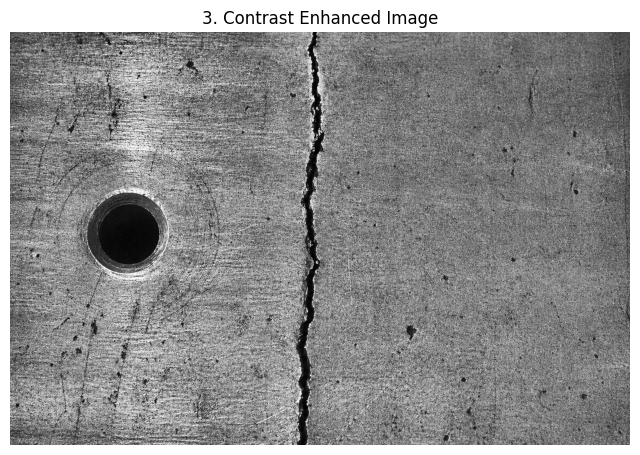

In [5]:
clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
contrast = clahe.apply(gray)

plt.imshow(contrast, cmap="gray")
plt.title("3. Contrast Enhanced Image")
plt.axis("off")
plt.show()

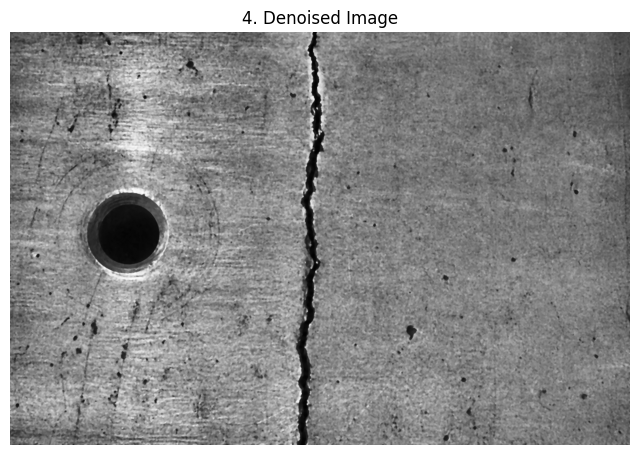

In [6]:
denoised = cv2.medianBlur(contrast, 5)

plt.imshow(denoised, cmap='gray')
plt.title('4. Denoised Image')
plt.axis('off')
plt.show()

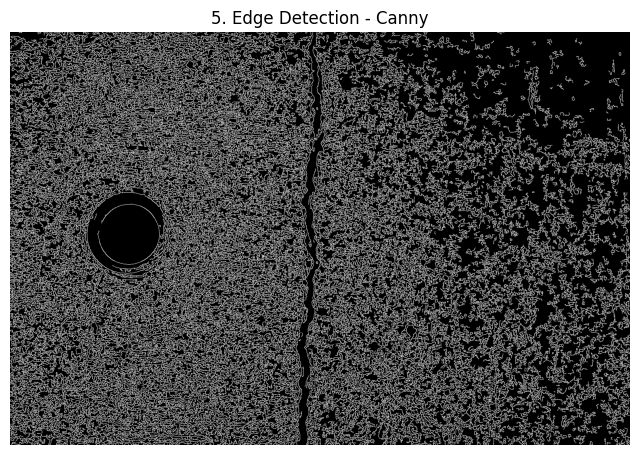

In [7]:
edges = cv2.Canny(denoised, 50, 150)

plt.imshow(edges, cmap="gray")
plt.title("5. Edge Detection - Canny")
plt.axis("off")
plt.show()

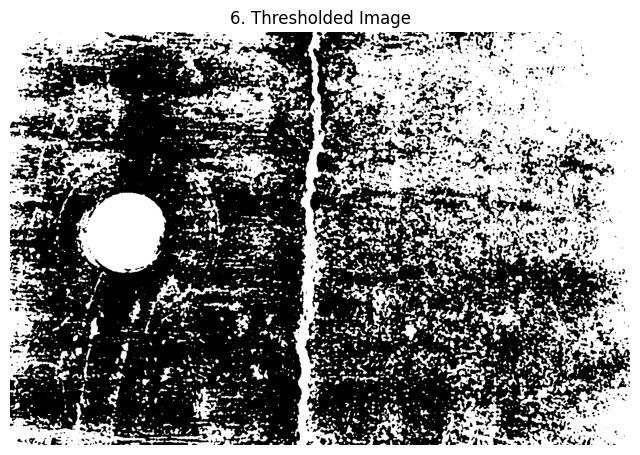

In [8]:
smooth = cv2.GaussianBlur(denoised, (5, 5), 0)

_, thresholded = cv2.threshold(
    smooth,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

plt.imshow(thresholded, cmap="gray")
plt.title("6. Thresholded Image")
plt.axis("off")
plt.show()

In [9]:
contours, _ = cv2.findContours(
    thresholded,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)


records = []

for i, cnt in enumerate(contours):
    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)

    if perimeter == 0:
        continue

    x, y, w, h = cv2.boundingRect(cnt)
    aspect_ratio = h / (w + 1)
    circularity = 4 * np.pi * area / (perimeter ** 2)

    records.append({
        "contour_id": i,
        "area": round(area, 2),
        "x": x,
        "y": y,
        "width": w,
        "height": h,
        "aspect_ratio": round(aspect_ratio, 2),
        "circularity": round(circularity, 3)
    })

df = pd.DataFrame(records)

df_sorted = df.sort_values("area", ascending=False).head(15)
df_sorted


,contour_id,area,x,y,width,height,aspect_ratio,circularity
2505,2652,388730.5,688,0,848,1024,1.21,0.015
2508,2655,80794.0,0,0,738,256,0.35,0.013
609,649,38997.0,1061,836,475,188,0.39,0.030
1956,2065,32559.0,163,400,224,198,0.88,0.394
2238,2370,20925.5,0,232,286,205,0.71,0.027
292,306,12668.0,0,920,381,104,0.27,0.050
2140,2265,6531.0,469,277,193,130,0.67,0.046
1313,1381,6373.0,0,641,106,138,1.29,0.072
874,925,4510.0,0,768,145,115,0.79,0.092
1212,1273,3365.5,1141,665,127,104,0.81,0.043


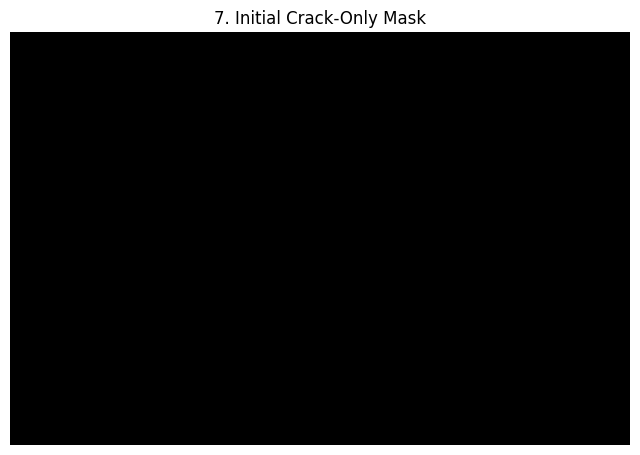

Total contours found: 2656
Crack-like contours kept: 0


In [10]:
crack_mask = np.zeros_like(gray)

MIN_AREA = 100
MIN_HEIGHT = 120
MAX_WIDTH = 180
MIN_ASPECT_RATIO = 3.0
MAX_CIRCULARITY = 0.60

kept_contours = []

for cnt in contours:
    area = cv2.contourArea(cnt)

    if area < MIN_AREA:
        continue

    perimeter = cv2.arcLength(cnt, True)

    if perimeter == 0:
        continue

    x, y, w, h = cv2.boundingRect(cnt)
    aspect_ratio = h / (w + 1)
    circularity = 4 * np.pi * area / (perimeter ** 2)

    is_crack_like = (
        h >= MIN_HEIGHT and
        w <= MAX_WIDTH and
        aspect_ratio >= MIN_ASPECT_RATIO and
        circularity <= MAX_CIRCULARITY
    )

    if is_crack_like:
        kept_contours.append(cnt)
        cv2.drawContours(crack_mask, [cnt], -1, 255, thickness=cv2.FILLED)

plt.imshow(crack_mask, cmap="gray")
plt.title("7. Initial Crack-Only Mask")
plt.axis("off")
plt.show()

print("Total contours found:", len(contours))
print("Crack-like contours kept:", len(kept_contours))

In [ ]:
if np.count_nonzero(crack_mask) == 0:
    print("The crack mask is empty. Running fallback selection...")

    candidate_contours = []

    for cnt in contours:
        area = cv2.contourArea(cnt)
        perimeter = cv2.arcLength(cnt, True)

        if perimeter == 0 or area < MIN_AREA:
            continue

        x, y, w, h = cv2.boundingRect(cnt)
        aspect_ratio = h / (w + 1)
        circularity = 4 * np.pi * area / (perimeter ** 2)

        if h >= 100 and aspect_ratio >= 2.0 and circularity <= 0.75:
            candidate_contours.append((cnt, area, x, y, w, h, aspect_ratio, circularity))

    if len(candidate_contours) > 0:
        candidate_contours = sorted(candidate_contours, key=lambda item: item[5], reverse=True)
        best_cnt = candidate_contours[0][0]
        cv2.drawContours(crack_mask, [best_cnt], -1, 255, thickness=cv2.FILLED)
        kept_contours = [best_cnt]
        print("Fallback selected one crack-like contour.")
    else:
        print("No suitable crack-like contour found. Try adjusting the thresholds.")

plt.imshow(crack_mask, cmap="gray")
plt.title("7. Crack-Only Mask After Fallback Check")
plt.axis("off")
plt.show()

print("White pixels in crack mask:", np.count_nonzero(crack_mask))

In [ ]:
if np.count_nonzero(crack_mask) == 0:
    print("The crack mask is empty. Running fallback selection...")

    candidate_contours = []

    for cnt in contours:
        area = cv2.contourArea(cnt)
        perimeter = cv2.arcLength(cnt, True)

        if perimeter == 0 or area < MIN_AREA:
            continue

        x, y, w, h = cv2.boundingRect(cnt)
        aspect_ratio = h / (w + 1)
        circularity = 4 * np.pi * area / (perimeter ** 2)

        if h >= 100 and aspect_ratio >= 2.0 and circularity <= 0.75:
            candidate_contours.append((cnt, area, x, y, w, h, aspect_ratio, circularity))

    if len(candidate_contours) > 0:
        candidate_contours = sorted(candidate_contours, key=lambda item: item[5], reverse=True)
        best_cnt = candidate_contours[0][0]
        cv2.drawContours(crack_mask, [best_cnt], -1, 255, thickness=cv2.FILLED)
        kept_contours = [best_cnt]
        print("Fallback selected one crack-like contour.")
    else:
        print("No suitable crack-like contour found. Try adjusting the thresholds.")

plt.imshow(crack_mask, cmap="gray")
plt.title("7. Crack-Only Mask After Fallback Check")
plt.axis("off")
plt.show()

print("White pixels in crack mask:", np.count_nonzero(crack_mask))

In [ ]:
kernel = np.ones((5, 5), np.uint8)

crack_mask_clean = cv2.morphologyEx(
    crack_mask,
    cv2.MORPH_CLOSE,
    kernel,
    iterations=2
)

crack_mask_clean = cv2.morphologyEx(
    crack_mask_clean,
    cv2.MORPH_OPEN,
    kernel,
    iterations=1
)

plt.imshow(crack_mask_clean, cmap="gray")
plt.title("7. Cleaned Crack-Only Defect Mask")
plt.axis("off")
plt.show()


In [ ]:
final_result = img.copy()

crack_contours, _ = cv2.findContours(
    crack_mask_clean,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

cv2.drawContours(final_result, crack_contours, -1, (255, 0, 0), 3)

plt.imshow(final_result)
plt.title("8. Final Result - Crack Detected Only")
plt.axis("off")
plt.show()

In [ ]:
measurements = []

for i, cnt in enumerate(crack_contours, start=1):
    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)
    x, y, w, h = cv2.boundingRect(cnt)
    aspect_ratio = h / (w + 1)

    measurements.append({
        "crack_id": i,
        "area_pixels": round(area, 2),
        "perimeter_pixels": round(perimeter, 2),
        "x": x,
        "y": y,
        "width_pixels": w,
        "height_pixels": h,
        "aspect_ratio": round(aspect_ratio, 2)
    })

pd.DataFrame(measurements)

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

pipeline_images = [
    (img, "1. Original Image", None),
    (gray, "2. Grayscale Image", "gray"),
    (contrast, "3. Contrast Enhanced", "gray"),
    (denoised, "4. Denoised Image", "gray"),
    (edges, "5. Edge Detection", "gray"),
    (thresholded, "6. Thresholded Image", "gray"),
    (crack_mask_clean, "7. Crack-Only Mask", "gray"),
    (final_result, "8. Final Crack Detection", None),
]

for ax, (img, title, cmap) in zip(axes.ravel(), pipeline_images):
    ax.imshow(img, cmap=cmap)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()